# Does SlotODE learn a continuous vector field?

Training: T=3, dt=1 → 3 Euler steps at t = 1, 2, 3.

Test: override dt0=0.1 at inference, save slots at t = 0.1, 0.2, ..., 3.0, decode → masks → ARI-FG at every timepoint.

Hypothesis:
- **Genuine vector field**: smooth curve, t=1,2,3 lie on it.
- **Collapsed to 3-step recurrence**: garbage between, spikes at t=1,2,3.

In [1]:
import pickle
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp
import equinox as eqx
import diffrax

from model import SlotODEModel
from evaluate import compute_ari_fg, compute_miou

print(jax.devices())

[CudaDevice(id=0)]


In [2]:
CKPT = 'runs_data/omkos-slotode/slot_ode_11_slots_euler_T5_dt1/checkpoints/best.eqx'
DATA_DIR = Path('CLEVR_64')
NUM_SAMPLES = 200
BATCH_SIZE = 16
RESOLUTION = (64, 64)
DT_FINE = 0.1  # fine integration step

meta_path = CKPT.replace('.eqx', '_meta.pkl')
with open(meta_path, 'rb') as f:
    meta = pickle.load(f)
ckpt_args = meta['args']
T = float(ckpt_args['num_iter'])
train_dt = ckpt_args.get('dt', 1.0)
num_slots = ckpt_args['num_slots']
print(f"Ckpt: T={T}, trained dt={train_dt}, step={meta['step']}")

# build model with fine dt0
key = jax.random.key(0)
model = SlotODEModel(
    resolution=RESOLUTION,
    num_slots=num_slots,
    slot_dim=ckpt_args['slot_dim'],
    enc_hidden_dim=ckpt_args.get('enc_hidden_dim', 64),
    num_iter=ckpt_args['num_iter'],
    dt0=DT_FINE,
    key=key,
)
model = eqx.tree_deserialise_leaves(CKPT, model)

ts = jnp.arange(0.0, T + DT_FINE, DT_FINE)
ts = jnp.clip(ts, 0.0, T)
ts_np = np.array(ts)
print(f"Saving {len(ts_np)} timepoints from t=0 to t={T} at dt={DT_FINE}")

Ckpt: T=5.0, trained dt=1.0, step=500000
Saving 51 timepoints from t=0 to t=5.0 at dt=0.1


In [3]:
# load eval data from CLEVR_64 folder (val split)
def load_val_data(data_dir, n, resolution):
    img_dir = data_dir / 'images' / 'val'
    mask_dir = data_dir / 'masks' / 'val'
    vis_dir = data_dir / 'visibility' / 'val'

    images, gt_segs = [], []
    for ip in sorted(img_dir.glob('*.png'))[:n]:
        stem = ip.stem
        mp = mask_dir / f'{stem}.npy'
        vp = vis_dir / f'{stem}.npy'
        if not mp.exists():
            continue

        img = np.array(Image.open(ip).convert('RGB'), dtype=np.float32) / 127.5 - 1.0
        img = np.transpose(img, (2, 0, 1))  # [3, H, W]
        images.append(img)

        masks = np.load(mp)  # [11, H, W]
        visibility = np.load(vp) if vp.exists() else np.ones(11, dtype=np.float32)
        seg = np.zeros((resolution[0], resolution[1]), dtype=np.int32)
        for obj_idx in range(1, 11):
            if visibility[obj_idx] > 0.5:
                seg[masks[obj_idx] > 127] = obj_idx
        gt_segs.append(seg)

    return np.stack(images), gt_segs

imgs_arr, segs = load_val_data(DATA_DIR, NUM_SAMPLES, RESOLUTION)
print(f"Loaded {imgs_arr.shape}, {len(segs)} GT segs")

Loaded (200, 3, 64, 64), 200 GT segs


In [4]:
# Two JIT'd helpers: integrate (returns full trajectory) + decode one timepoint at a time.
@eqx.filter_jit
def get_traj(model, images, key):
    enc_feat = model.enc(images)
    _, traj = model.slot_attention_ode(enc_feat, key, return_traj=True)
    return traj  # [n_times, B, N_slots, D]

@eqx.filter_jit
def decode_slots(model, slots_t):
    _, masks_t = model.dec(slots_t)
    return masks_t  # [B, N, H, W]

In [5]:
# Sequential sweep: integrate once per batch, decode each timepoint serially.
n_t = len(ts_np)
ari_per_t = [[] for _ in range(n_t)]

key = jax.random.key(0)
for start in range(0, len(imgs_arr), BATCH_SIZE):
    batch = jnp.array(imgs_arr[start:start + BATCH_SIZE])
    key, sk = jax.random.split(key)
    traj = get_traj(model, batch, sk)  # [n_t, B, N, D] on device
    end = start + batch.shape[0]
    for ti in range(n_t):
        masks_t = np.array(decode_slots(model, traj[ti]))  # [B, N, H, W]
        for bi in range(masks_t.shape[0]):
            pred_mask = masks_t[bi].argmax(axis=0)
            gt = segs[start + bi]
            ari_per_t[ti].append(compute_ari_fg(pred_mask, gt))
        del masks_t
    del traj
    print(f"  batch {start:>4}..{end:<4}  ARI(t=0)={np.mean(ari_per_t[0]):.4f}  "
          f"ARI(t={ts_np[-1]:.1f})={np.mean(ari_per_t[-1]):.4f}")

ari_mean = np.array([np.mean(a) for a in ari_per_t])
ari_std  = np.array([np.std(a)  for a in ari_per_t])
print(f"\nsweep done: {n_t} timepoints, {len(ari_per_t[0])} samples each")
print(f"ARI-FG: t=0 -> {ari_mean[0]:.4f}    t={T} -> {ari_mean[-1]:.4f}")

  batch    0..16    ARI(t=0)=0.1620  ARI(t=5.0)=0.9877
  batch   16..32    ARI(t=0)=0.1667  ARI(t=5.0)=0.9863
  batch   32..48    ARI(t=0)=0.1506  ARI(t=5.0)=0.9827
  batch   48..64    ARI(t=0)=0.1514  ARI(t=5.0)=0.9857
  batch   64..80    ARI(t=0)=0.1534  ARI(t=5.0)=0.9868
  batch   80..96    ARI(t=0)=0.1548  ARI(t=5.0)=0.9863
  batch   96..112   ARI(t=0)=0.1483  ARI(t=5.0)=0.9851
  batch  112..128   ARI(t=0)=0.1406  ARI(t=5.0)=0.9853
  batch  128..144   ARI(t=0)=0.1418  ARI(t=5.0)=0.9855
  batch  144..160   ARI(t=0)=0.1409  ARI(t=5.0)=0.9858
  batch  160..176   ARI(t=0)=0.1424  ARI(t=5.0)=0.9854
  batch  176..192   ARI(t=0)=0.1450  ARI(t=5.0)=0.9850
  batch  192..200   ARI(t=0)=0.1441  ARI(t=5.0)=0.9845

sweep done: 51 timepoints, 200 samples each
ARI-FG: t=0 -> 0.1441    t=5.0 -> 0.9845


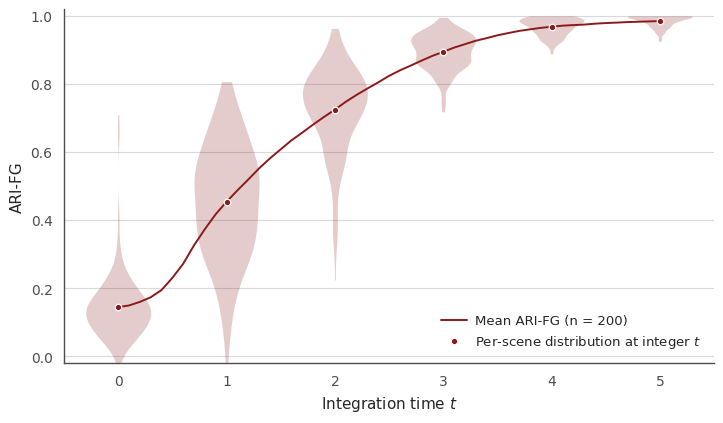

saved vector_field_probe.json + thesis_draft/figures/vector_field_probe.png


In [6]:
import json
import seaborn as sns

sns.set_theme(style="white", context="paper", font_scale=1.25)

line_color = "#8b1a1a"  # darker red

# Pick integer-t indices for the violins (one per Euler training step + t=0)
integer_ts = np.arange(0.0, T + 1e-6, 1.0)
integer_idxs = [int(round(t / DT_FINE)) for t in integer_ts]
violin_data = [np.array(ari_per_t[idx]) for idx in integer_idxs]

fig, ax = plt.subplots(figsize=(7.4, 4.4))

# violins at integer t — show the per-scene distribution
parts = ax.violinplot(
    violin_data, positions=integer_ts, widths=0.6,
    showmeans=False, showmedians=False, showextrema=False,
)
for body in parts["bodies"]:
    body.set_facecolor(line_color)
    body.set_edgecolor(line_color)
    body.set_alpha(0.22)
    body.set_linewidth(0.0)

# thin mean line through all fine timepoints, so the continuous-time story is preserved
ax.plot(ts_np, ari_mean, "-", color=line_color, linewidth=1.4, zorder=4,
        label=f"Mean ARI-FG (n = {NUM_SAMPLES})")

# small markers at the violin centers for the per-integer-t mean
violin_means = np.array([d.mean() for d in violin_data])
ax.scatter(integer_ts, violin_means, color=line_color, s=22, zorder=5,
           edgecolor="white", linewidth=0.9, label="Per-scene distribution at integer $t$")

# spines + grid
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.spines["left"].set_color("0.3"); ax.spines["bottom"].set_color("0.3")
ax.tick_params(axis="both", colors="0.3", labelsize=10)
ax.yaxis.grid(True, color="0.85", linewidth=0.8)
ax.set_axisbelow(True)

ax.set_xlabel("Integration time $t$", fontsize=11)
ax.set_ylabel("ARI-FG", fontsize=11)
ax.set_xlim(-0.5, T + 0.5)
ax.set_xticks(integer_ts)
ax.set_ylim(-0.02, 1.02)

# Legend tucked into the empty lower-right area inside the axes
ax.legend(fontsize=9.5, loc="lower right", frameon=False, handlelength=2.0,
          handletextpad=0.6, labelspacing=0.4, borderaxespad=0.6)

fig.tight_layout()
fig.savefig("thesis_draft/figures/vector_field_probe.png", dpi=220, bbox_inches="tight")
fig.savefig("vector_field_probe.png", dpi=150, bbox_inches="tight")
plt.show()

out = {
    "ts": ts_np.tolist(),
    "ari_mean": ari_mean.tolist(),
    "ari_std": ari_std.tolist(),
    "train_dt": train_dt, "T": T, "dt_fine": DT_FINE,
    "num_samples": NUM_SAMPLES, "ckpt": CKPT, "step": meta["step"],
}
with open("vector_field_probe.json", "w") as f:
    json.dump(out, f, indent=2)
print("saved vector_field_probe.json + thesis_draft/figures/vector_field_probe.png")